## 2D Linear Convection — Revisited

In [`01_convection_petsc.ipynb`](01_convection_petsc.ipynb) we used a hat-function initial condition whose sharp corners cause numerical diffusion with both schemes. Here we repeat the experiment with a **smooth** $C^\infty$ bump so that the finite-difference approximations are well-posed.

The governing equation and both PETSc-based schemes are unchanged:

$$\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} + c\frac{\partial u}{\partial y} = 0$$

| Scheme | Spatial terms | Stability |
|--------|--------------|----------|
| **Explicit** | `u.dxl`, `u.dyl` — current level $n$ | CFL-limited: $\sigma \leq 1$ |
| **Implicit** | `u.forward.dxl`, `u.forward.dyl` — next level $n+1$ | Unconditionally stable |

With a smooth initial condition the two results are nearly indistinguishable at $\sigma = 0.2$, confirming both correctly transport the wave.

## Grid and parameters

In [1]:
import os
os.environ['PETSC_DIR']  = '/home/zl5621/petsc'
os.environ['PETSC_ARCH'] = 'zoe-petsc-section'
os.environ['CC']         = 'mpicc'

from examples.cfd import plot_field, init_smooth
import numpy as np
%matplotlib inline

nx = 81
ny = 81
nt = 100
c  = 1.
dx = 2. / (nx - 1)
dy = 2. / (ny - 1)
sigma = 0.2
dt = sigma * dx

print(f'dx={dx:.4f}  dy={dy:.4f}  dt={dt:.5f}  CFL={c*dt/dx:.2f}')

dx=0.0250  dy=0.0250  dt=0.00500  CFL=0.20


The smooth initial condition is a $C^\infty$ bump centred near $(0.75, 0.75)$ over a background of 1. Unlike the hat function it has no discontinuities.

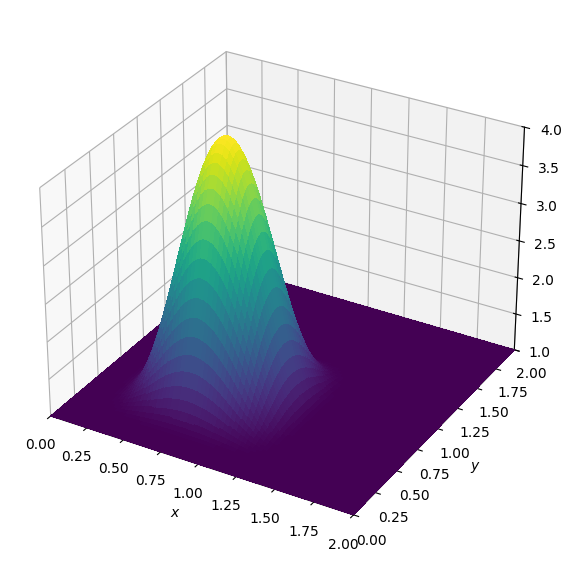

In [2]:
#NBVAL_IGNORE_OUTPUT
u_np = np.empty((nx, ny))
init_smooth(field=u_np, dx=dx, dy=dy)
plot_field(u_np, zmax=4)

## PETSc setup

Environment, imports, subdomains, and shared grid — identical to `01_convection_petsc.ipynb`.

In [3]:
from devito import (Grid, TimeFunction, Function, Eq,
                    Operator, switchconfig, configuration, SubDomain)
from devito.petsc import petscsolve, EssentialBC
from devito.petsc.initialize import PetscInitialize

configuration['compiler'] = 'custom'
PetscInitialize()

Operator `kernel_init` ran in 0.06 s


In [4]:
class SubTop(SubDomain):
    name = 'subtop'
    def define(self, dimensions):
        x, y = dimensions
        return {x: x, y: ('right', 1)}

class SubBottom(SubDomain):
    name = 'subbottom'
    def define(self, dimensions):
        x, y = dimensions
        return {x: x, y: ('left', 1)}

class SubLeft(SubDomain):
    name = 'subleft'
    def define(self, dimensions):
        x, y = dimensions
        return {x: ('left', 1), y: ('middle', 1, 1)}

class SubRight(SubDomain):
    name = 'subright'
    def define(self, dimensions):
        x, y = dimensions
        return {x: ('right', 1), y: ('middle', 1, 1)}

sub1 = SubTop(); sub2 = SubBottom()
sub3 = SubLeft(); sub4 = SubRight()
subdomains = (sub1, sub2, sub3, sub4)

In [5]:
# float64 required by the PETSc build
grid = Grid(shape=(nx, ny), extent=(2., 2.),
            subdomains=subdomains, dtype=np.float64)

bc_val = Function(name='bc_val', grid=grid)
bc_val.data[:] = 1.

## Explicit scheme

Spatial terms evaluated at the current time level. The Jacobian w.r.t. `u.forward` is diagonal ($I/\Delta t$), so the KSP converges in a single iteration.

/home/zl5621/devito_original/devito/devito/symbolics/unevaluation.py:9: SymPyDeprecationWarning: 

Using non-Expr arguments in Mul is deprecated (in this case, one of
the arguments has type 'PetscInt').

If you really did intend to use a multiplication or addition operation with
this object, use the * or + operator instead.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#non-expr-args-deprecated
for details.

This has been deprecated since SymPy version 1.7. It
will be removed in a future version of SymPy.

  return cls.__base__.__new__(cls, *args, evaluate=False, **kwargs)
Operator `Kernel` ran in 0.07 s


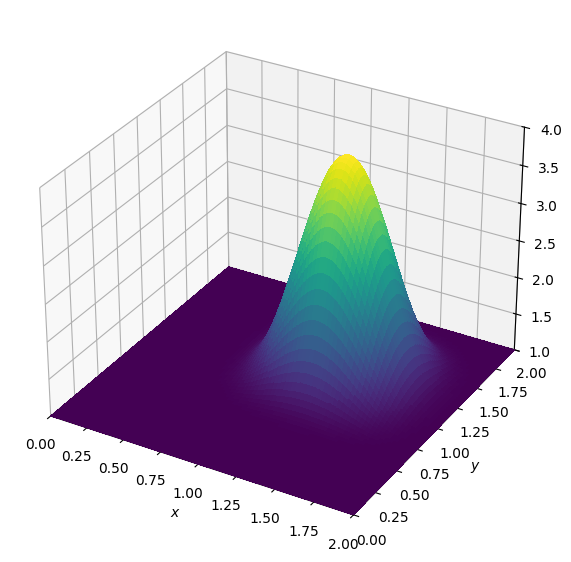

In [6]:
#NBVAL_IGNORE_OUTPUT
u_expl = TimeFunction(name='u_expl', grid=grid,
                      space_order=1, save=nt+1)

init_smooth(field=u_expl.data[0], dx=dx, dy=dy)
u_expl.data[0, 0, :]  = 1.;  u_expl.data[0, -1, :] = 1.
u_expl.data[0, :, 0]  = 1.;  u_expl.data[0, :, -1] = 1.

eqn_expl = Eq(u_expl.dt + c*u_expl.dxl + c*u_expl.dyl, 0,
              subdomain=grid.interior)

bcs  = [EssentialBC(u_expl.forward, bc_val, subdomain=sub1)]
bcs += [EssentialBC(u_expl.forward, bc_val, subdomain=sub2)]
bcs += [EssentialBC(u_expl.forward, bc_val, subdomain=sub3)]
bcs += [EssentialBC(u_expl.forward, bc_val, subdomain=sub4)]

petsc_expl = petscsolve([eqn_expl] + bcs, target=u_expl.forward,
                        solver_parameters={'ksp_type': 'gmres',
                                           'ksp_rtol': 1e-9})
with switchconfig(language='petsc'):
    op_expl = Operator(petsc_expl)
    op_expl.apply(dt=dt)

plot_field(u_expl.data[nt].astype(float), zmax=4)

## Implicit scheme

Spatial terms moved to the next time level. The Jacobian is non-trivial and GMRES solves the system at each step. As in the previous notebook, only `u.dxl` → `u.forward.dxl` and `u.dyl` → `u.forward.dyl` differ from the explicit form.

/home/zl5621/devito_original/devito/devito/symbolics/unevaluation.py:9: SymPyDeprecationWarning: 

Using non-Expr arguments in Mul is deprecated (in this case, one of
the arguments has type 'PetscInt').

If you really did intend to use a multiplication or addition operation with
this object, use the * or + operator instead.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#non-expr-args-deprecated
for details.

This has been deprecated since SymPy version 1.7. It
will be removed in a future version of SymPy.

  return cls.__base__.__new__(cls, *args, evaluate=False, **kwargs)
Operator `Kernel` ran in 0.21 s


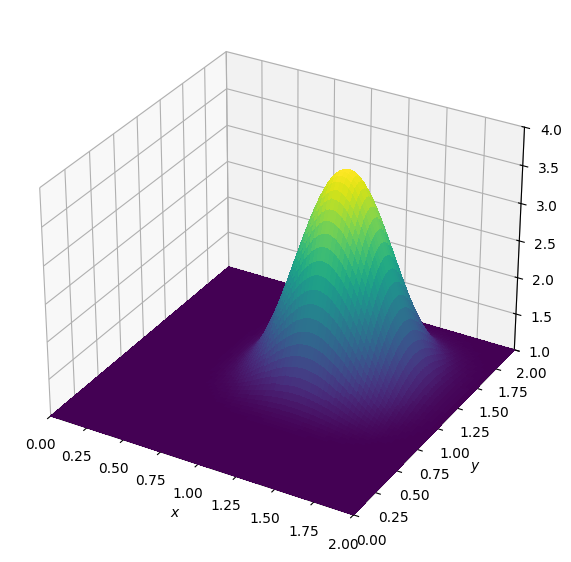

In [7]:
#NBVAL_IGNORE_OUTPUT
u_impl = TimeFunction(name='u_impl', grid=grid,
                      space_order=1, save=nt+1)

init_smooth(field=u_impl.data[0], dx=dx, dy=dy)
u_impl.data[0, 0, :]  = 1.;  u_impl.data[0, -1, :] = 1.
u_impl.data[0, :, 0]  = 1.;  u_impl.data[0, :, -1] = 1.
# Warm-start all time levels with the initial condition
u_impl.data[1:] = u_impl.data[0]

eqn_impl = Eq(u_impl.dt + c*u_impl.forward.dxl + c*u_impl.forward.dyl, 0,
              subdomain=grid.interior)

bcs  = [EssentialBC(u_impl.forward, bc_val, subdomain=sub1)]
bcs += [EssentialBC(u_impl.forward, bc_val, subdomain=sub2)]
bcs += [EssentialBC(u_impl.forward, bc_val, subdomain=sub3)]
bcs += [EssentialBC(u_impl.forward, bc_val, subdomain=sub4)]

petsc_impl = petscsolve([eqn_impl] + bcs, target=u_impl.forward,
                        solver_parameters={'ksp_type': 'gmres',
                                           'ksp_rtol': 1e-9})
with switchconfig(language='petsc'):
    op_impl = Operator(petsc_impl)
    op_impl.apply(dt=dt)

plot_field(u_impl.data[nt].astype(float), zmax=4)

## Note on explicit vs implicit

With the smooth initial condition and $\sigma = 0.2$ both schemes give nearly identical results — the wave is transported without noticeable distortion. The key difference is stability: the explicit scheme requires $\sigma \leq 1$, while the implicit scheme is unconditionally stable. For time-accurate problems the extra cost of a non-trivial KSP solve per step is often worth paying to use a larger $\Delta t$.